R² : 0.09393371894977776
RMSE : 0.1838015478702438


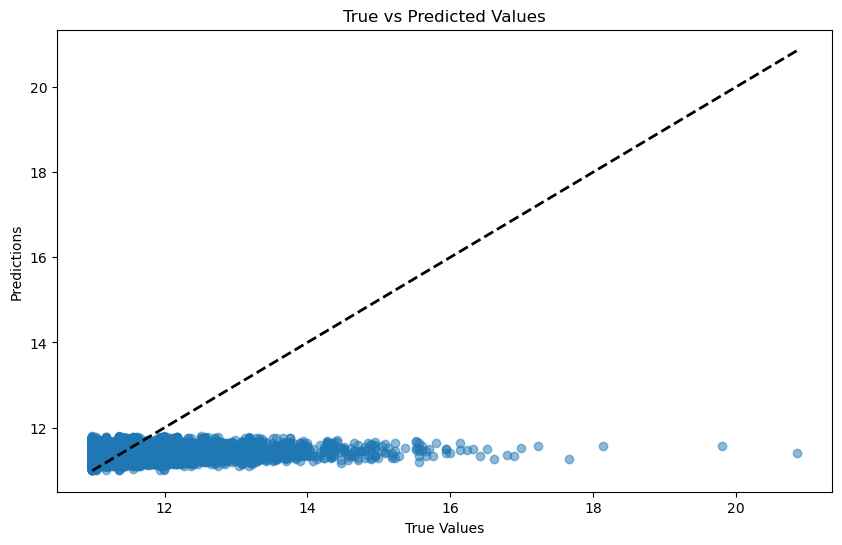

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "score_bayes_preprocessed.csv")
df = pd.read_csv(path)

# --- 1. Split
X = df.drop(columns="score_bayes")
y = df["score_bayes"]

# Tous les champs sont catégoriels → on les convertit en string
X = X.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- 2. Pipeline : OHE (sparse) + régression linéaire
pipe = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore", dtype=np.uint8)),
    ("reg", LinearRegression())
])

# --- 3. Entraînement
pipe.fit(X_train, y_train)

# --- 4. Prédiction & métriques
y_pred = pipe.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
print("R² :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred)) 

# === 5. Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

R² : 0.11067492396592815
RMSE: 0.18040548352093935


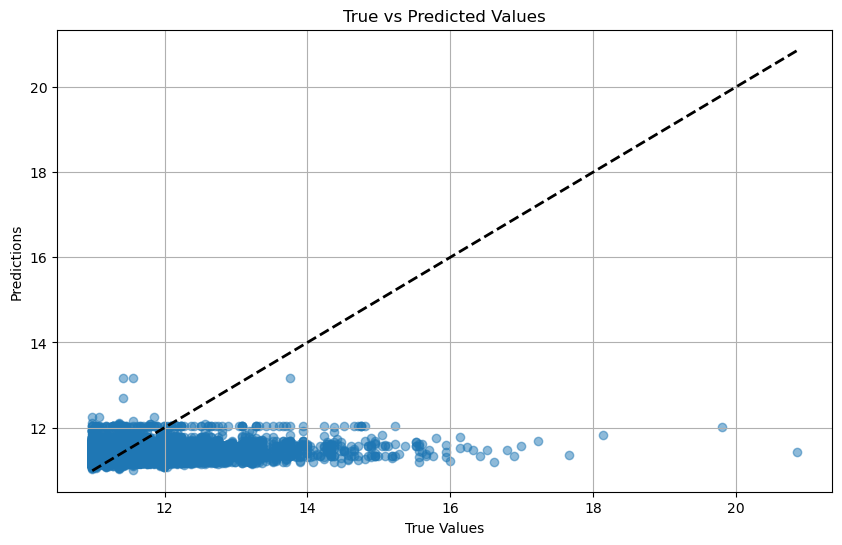

In [ ]:
##################
# XGBoost 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# Importation des données   

path = os.path.join("..", "data", "processed", "score_bayes_preprocessed.csv")
df = pd.read_csv(path)          

# Train/test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

# === 2. Transformation log sur la cible
y_train = np.log1p(y_train_raw)
y_test  = np.log1p(y_test_raw)

# One-hot (sparse=True par défaut)
ohe = OneHotEncoder(handle_unknown='ignore')
preproc = ColumnTransformer([('ohe', ohe, X.columns)], remainder='drop')

# Pipeline : OHE → XGB
xgb = XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        tree_method='hist',            # accélère sur gros OHE
        eval_metric='rmse',
        n_jobs=-1,
        random_state=42)

pipe = Pipeline([('prep', preproc), ('xgb', xgb)])

pipe.fit(X_train, np.log1p(y_train_raw))             # on reste en log1p
y_pred_log = pipe.predict(X_test)
y_pred = np.expm1(y_pred_log)

print('R² :', r2_score(y_test_raw, y_pred))
print('RMSE:', mean_squared_error(y_test_raw, y_pred))

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()

Poisson  R² : 0.07980747118530451
Poisson RMSE: 0.18666715081675145


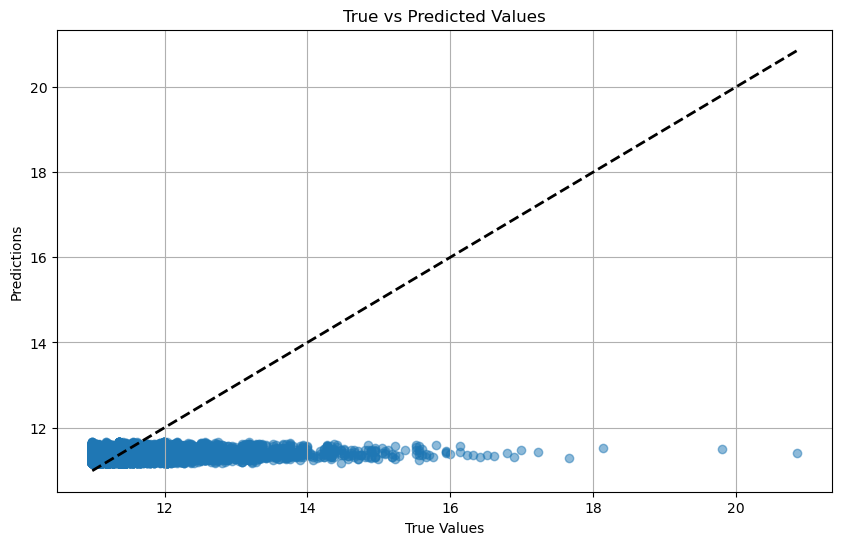

In [ ]:
#################
# Poisson Regression
#################

import os
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# Importation des données   

path = os.path.join("..", "data", "processed", "score_bayes_preprocessed.csv")
df = pd.read_csv(path)          

# --- Split
X = df.drop(columns=['score_bayes']).astype(str)
y = df['score_bayes']                       # déjà positive

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- One-Hot (sparse=True par défaut)
ohe = OneHotEncoder(handle_unknown='ignore')
preproc = ColumnTransformer([('ohe', ohe, X.columns)], remainder='drop')

# --- Pipeline Poisson
pipe_poisson = Pipeline([
    ('prep', preproc),
    ('glm',  PoissonRegressor(alpha=1.0, max_iter=300))   # alpha = régularisation L2
])

pipe_poisson.fit(X_train, y_train)
y_pred = pipe_poisson.predict(X_test)

print("Poisson  R² :", r2_score(y_test, y_pred))
print("Poisson RMSE:", mean_squared_error(y_test, y_pred))

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 88
[LightGBM] [Info] Number of data points in the train set: 197590, number of used features: 44
[LightGBM] [Info] Start training from score 11.338845


/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM R² : 0.10789844981257857
LightGBM RMSE: 0.18096870969730236


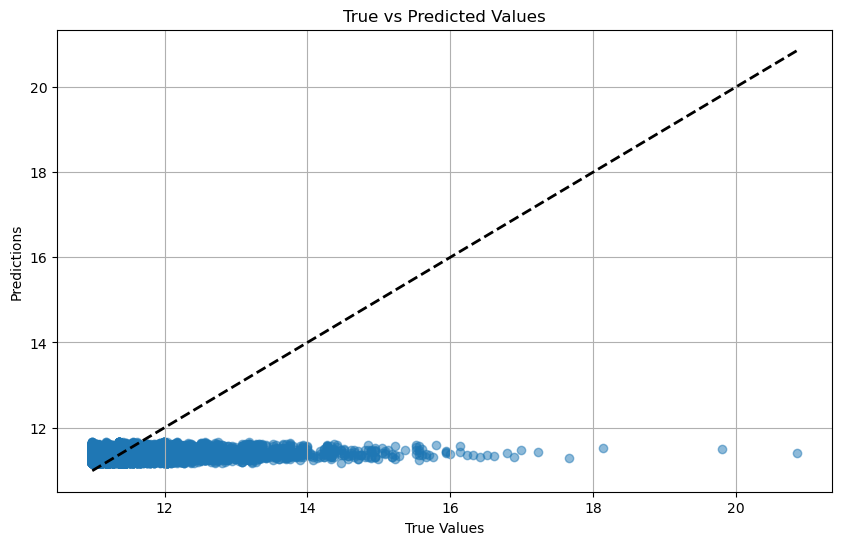

In [6]:
#################
# LightGBM Regressor
#################

import os
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

# Importation des données   

path = os.path.join("..", "data", "processed", "score_bayes_preprocessed.csv")
df = pd.read_csv(path)          

# --- Split
X = df.drop(columns=['score_bayes']).astype(str)
y = df['score_bayes']                       # déjà positive

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- One-Hot (sparse=True par défaut)
ohe = OneHotEncoder(handle_unknown='ignore')
preproc = ColumnTransformer([('ohe', ohe, X.columns)], remainder='drop')

# --- LightGBM params
lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression_l2',   # MSE
    random_state=42,
    n_jobs=-1)

pipe_lgbm = Pipeline([
    ('prep', preproc),           # même One-Hot que plus haut
    ('lgb',  lgbm)
])

pipe_lgbm.fit(X_train, y_train)
y_pred_lgb = pipe_lgbm.predict(X_test)

print("LightGBM R² :", r2_score(y_test, y_pred_lgb))
print("LightGBM RMSE:", mean_squared_error(y_test, y_pred_lgb))

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()
